C:\Users\yerayhurdra\AppData\Local\Temp\ipykernel_1836\3375872552.py:28: DtypeWarning: Columns (112) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv')


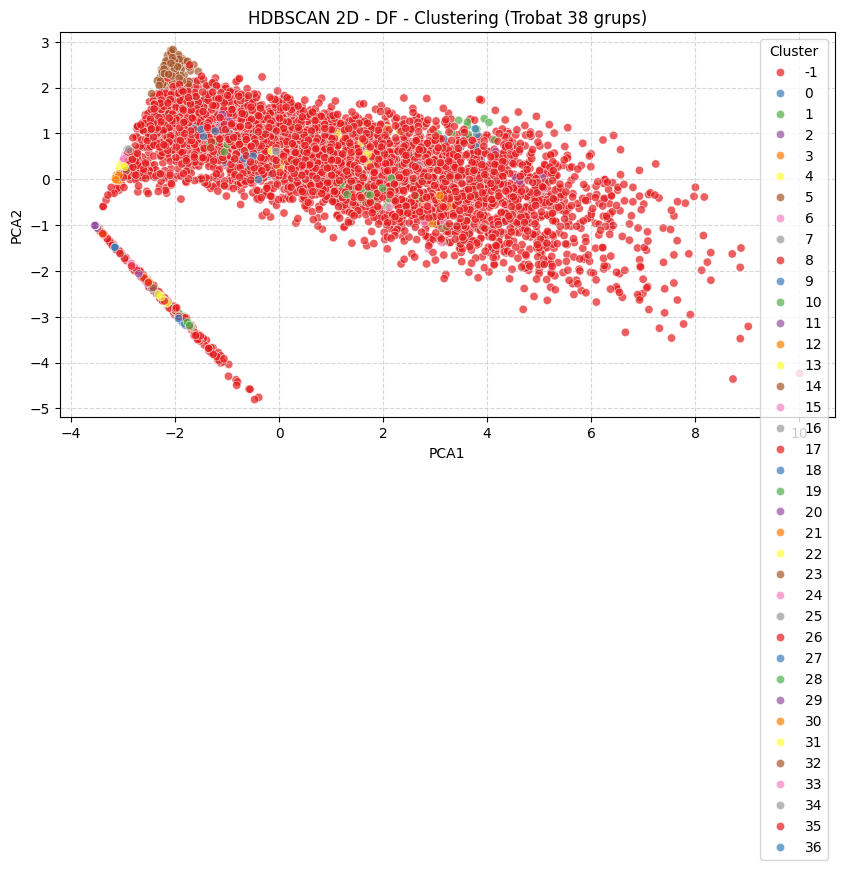

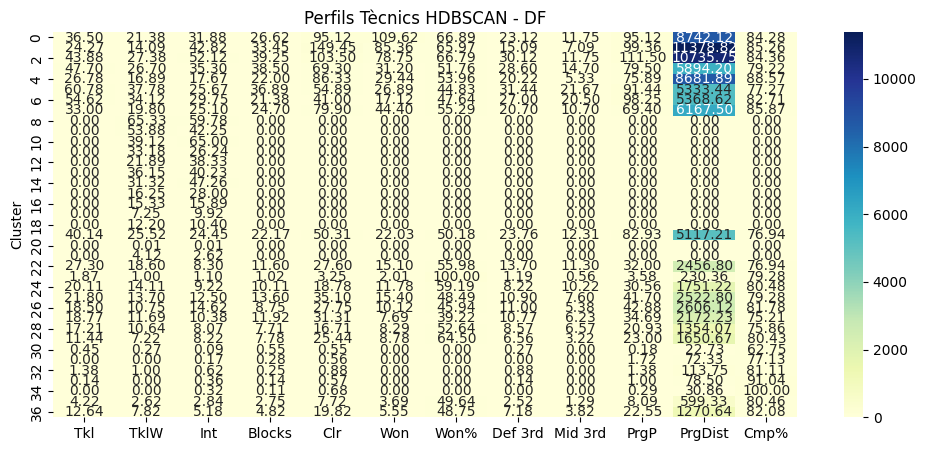

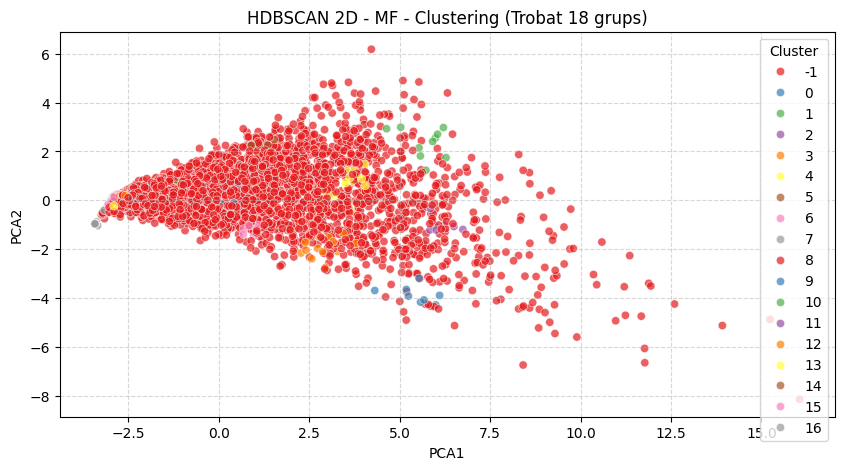

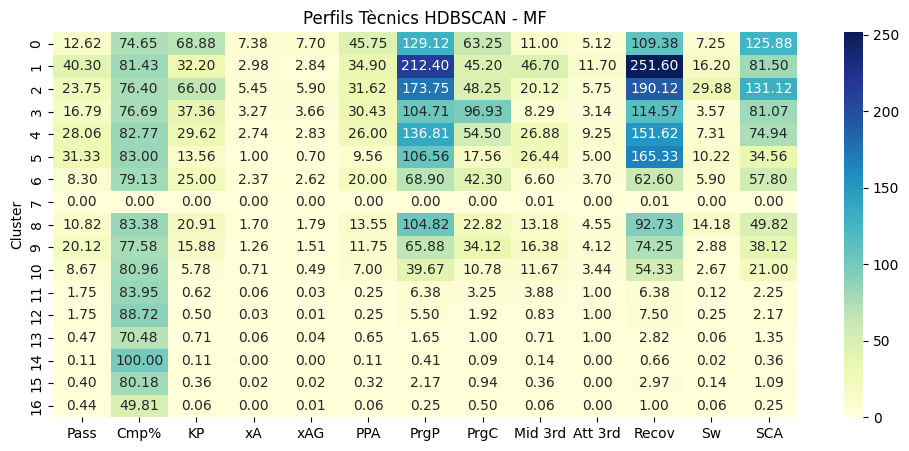

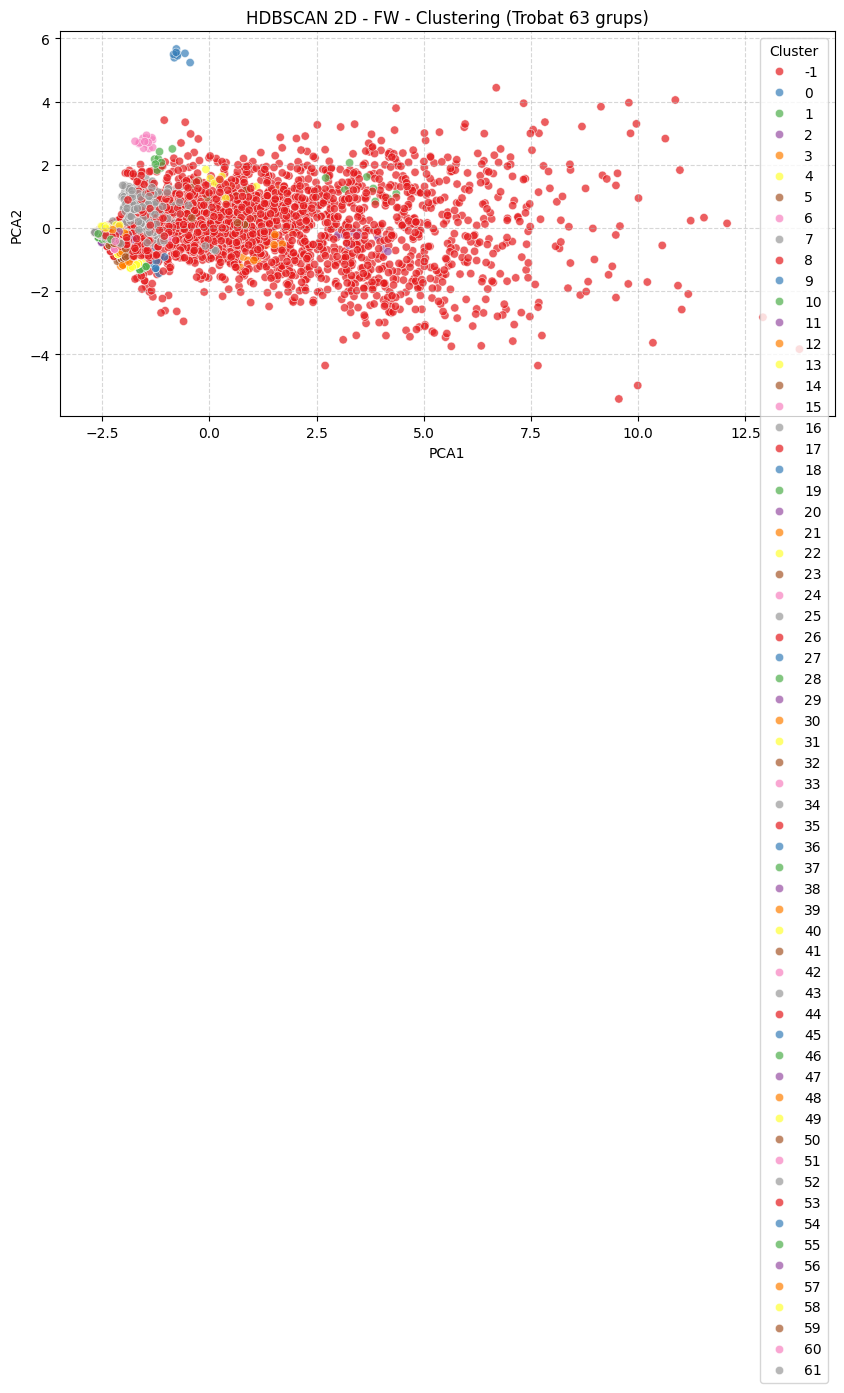

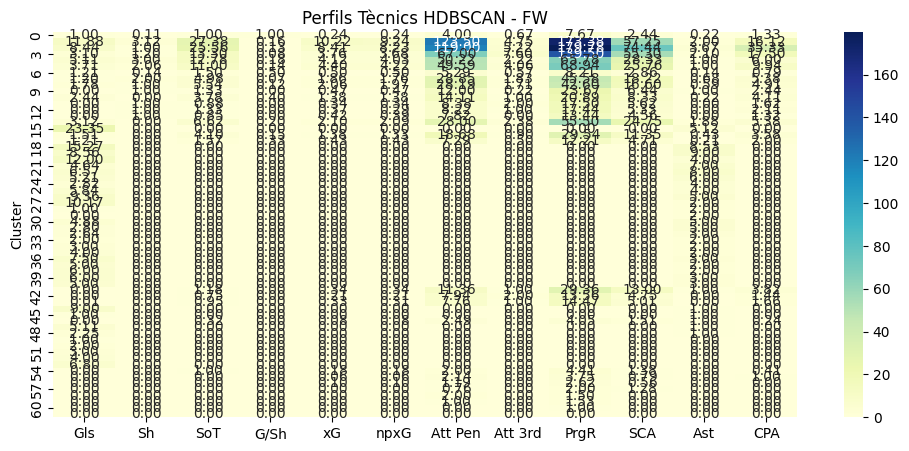

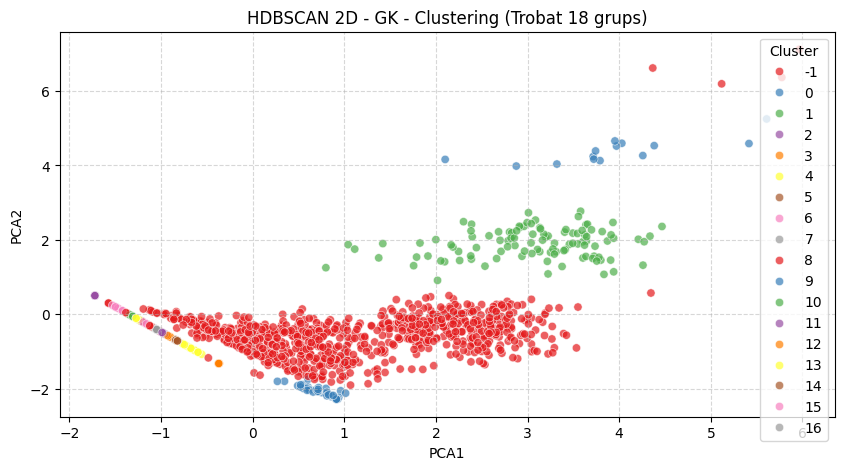

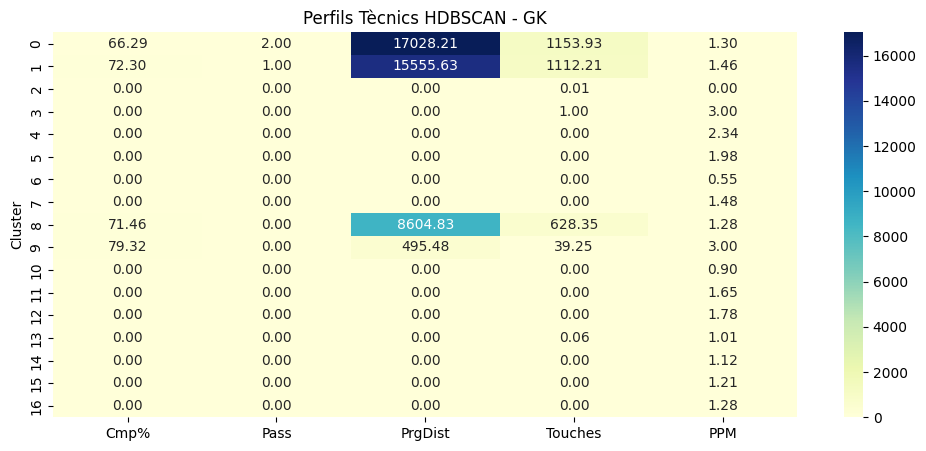


RESUM GLOBAL DE RENDIMENT (Sense incloure soroll):
  Posició  N_Clusters  Outliers (Noise)  Silhouette  Davies-Bouldin
0      DF          38              3890    0.669513        1.009303
1      MF          18              3444    0.701485        0.829298
2      FW          63              2138    0.488748        0.937729
3      GK          18                31    0.550017        0.582647


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Configuració de mètriques per posició
FEATURES_BY_POS = {
    'df': ['Tkl', 'TklW', 'Int', 'Blocks', 'Clr', 'Won', 'Won%', 'Def 3rd', 'Mid 3rd', 'PrgP', 'PrgDist', 'Cmp%'],
    'mf': ['Pass', 'Cmp%', 'KP', 'xA', 'xAG', 'PPA', 'PrgP', 'PrgC', 'Mid 3rd', 'Att 3rd', 'Recov', 'Sw', 'SCA'],
    'fw': ['Gls', 'Sh', 'SoT', 'G/Sh', 'xG', 'npxG', 'Att Pen', 'Att 3rd', 'PrgR', 'SCA', 'Ast', 'CPA'],
    'gk': ['Cmp%', 'Pass', 'PrgDist', 'Touches', 'PPM']
}

def plot_pca_hdbscan(df, pos, title, cluster_col=None):
    plt.figure(figsize=(10, 5))
    # Utilitzem 'Set1' perquè el -1 (soroll) sol sortir en un color clar/gris segons la paleta
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue=cluster_col, palette='Set1' if cluster_col else None, alpha=0.7)
    plt.title(f"HDBSCAN 2D - {pos.upper()} - {title}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Procés principal ---

df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv')
df_raw['Pos_Main'] = df_raw['Pos'].str.split(',').str[0].str.lower()

results_summary = []

for pos, metrics in FEATURES_BY_POS.items():
    pos_df = df_raw[df_raw['Pos_Main'] == pos].copy()
    if len(pos_df) < 15: continue

    # Preprocessament
    X = pos_df[metrics].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)

    # 1. PCA
    pca = PCA(n_components=3)
    pca_res = pca.fit_transform(X_scaled)
    pos_df['PCA1'], pos_df['PCA2'], pos_df['PCA3'] = pca_res[:,0], pca_res[:,1], pca_res[:,2]

    # 2. Clustering HDBSCAN
    # min_cluster_size: Mínim de jugadors per formar un perfil
    # min_samples: Com de conservador és el model (més alt = més soroll)
    hdb = HDBSCAN(min_cluster_size=8, min_samples=3)
    pos_df['Cluster'] = hdb.fit_predict(X_scaled)

    # 3. Avaluació (Només si s'han trobat almenys 2 clústers + soroll no compta per silhouette)
    labels = pos_df['Cluster']
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Mètriques només per als punts que NO són soroll
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
        db = davies_bouldin_score(X_scaled[mask], labels[mask])
        
        results_summary.append({
            'Posició': pos.upper(),
            'N_Clusters': n_clusters,
            'Outliers (Noise)': np.sum(~mask),
            'Silhouette': sil,
            'Davies-Bouldin': db
        })
    else:
        sil, db = 0, 0
        print(f"Avís: HDBSCAN no ha trobat prou clústers per a {pos.upper()}")

    # 4. Visualització
    plot_pca_hdbscan(pos_df, pos, f"Clustering (Trobat {n_clusters} grups)", cluster_col='Cluster')

    # 5. Mapa de Calor dels Perfils (Excloent soroll)
    if n_clusters > 0:
        cluster_profile = pos_df[pos_df['Cluster'] != -1].groupby('Cluster')[metrics].mean()
        plt.figure(figsize=(12, 5))
        sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
        plt.title(f"Perfils Tècnics HDBSCAN - {pos.upper()}")
        plt.show()

# Resum final
df_metrics = pd.DataFrame(results_summary)
print("\nRESUM GLOBAL DE RENDIMENT (Sense incloure soroll):")
print(df_metrics)